Módulo EBAC - Visualização de Dados


In [ ]:
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [ ]:
uploaded = files.upload()
df = pd.read_csv('ecommerce_estatistica.csv')
print(df.head())
print(df.columns)

# Análise dos dados

In [ ]:
print('          Análise dos dados da E-Commerce              ')

total_produtos = len(df)
print(f' Total produtos: {total_produtos}')
total_vendas = df['Qtd_Vendidos_Cod'].sum()
print(f' Total de Unidades Vendidas: {total_vendas}')
preco_medio = df['Preço'].mean()
print(f'Preço Médio dos Produtos: {preco_medio}')
nota_media = df['Nota'].mean()
print(f'Avaliação média dos produtos: {nota_media}')
faturamento_total = (df['Preço']* df['Qtd_Vendidos_Cod']).sum()
print(f' Faturamento Bruto Estimando: {faturamento_total:,.2f}')

          Análise dos dados da E-Commerce              
 Total produtos: 295
 Total de Unidades Vendidas: 869160.0
Preço Médio dos Produtos: 130.8366440677966
Avaliação média dos produtos: 4.4806779661016956
 Faturamento Bruto Estimando: 131,300,060.90



# Concentração por Marca

In [ ]:
df['Faturamento_Item'] = df['Preço'] * df['Qtd_Vendidos_Cod']

fat_marca = df.groupby('Marca')['Faturamento_Item'].agg(['sum', 'count']).sort_values(by='sum', ascending=False)
fat_marca['share'] = (fat_marca['sum'] / faturamento_total) * 100
fat_marca['cum_share'] = fat_marca['share'].cumsum()

print('\n         Concentralção por Marca       ')
print(fat_marca.head(10).round(2))


         Concentralção por Marca       
                   sum  count  share  cum_share
Marca                                          
zorba       51355160.0     10  39.11      39.11
lupo        29652302.0     40  22.58      61.70
zaroc       11955500.0      1   9.11      70.80
mash        11891646.0      9   9.06      79.86
almix        6715000.0      5   5.11      84.97
celi         2832180.0     15   2.16      87.13
keeper       1991096.5      8   1.52      88.65
moralice     1898800.0      1   1.45      90.09
moda llevo   1791500.0      1   1.36      91.46
stillger     1066567.5     16   0.81      92.27


# Gráfico de Histograma

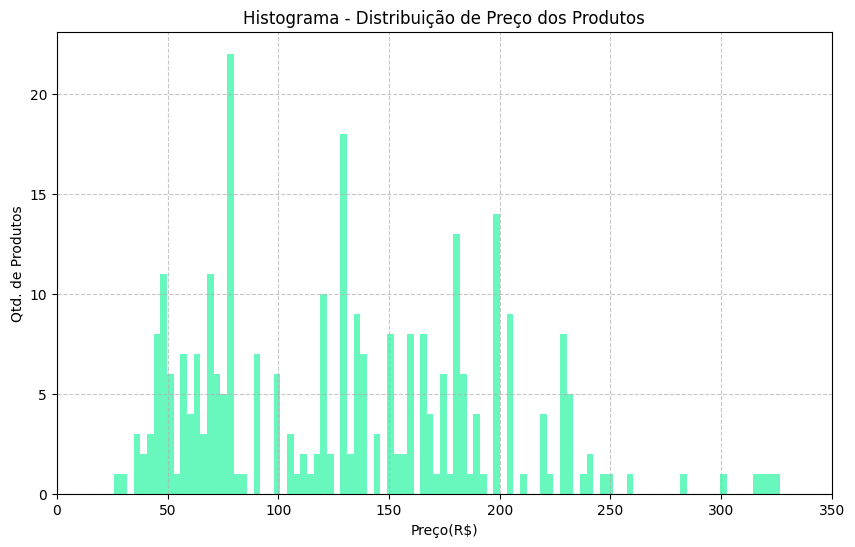

In [ ]:
plt.figure(figsize = (10,6))
plt.hist(df['Preço'], bins = 100, color = '#42f5ad', alpha = 0.8)
plt.title('Histograma - Distribuição de Preço dos Produtos')
plt.xlabel('Preço(R$)')
plt.xticks(ticks=range(0, int(df['Preço'].max())+ 50, 50))
plt.ylabel('Qtd. de Produtos')
plt.grid(True, linestyle = '--', alpha=0.7)
plt.show()

# Gráfico de Dispersão

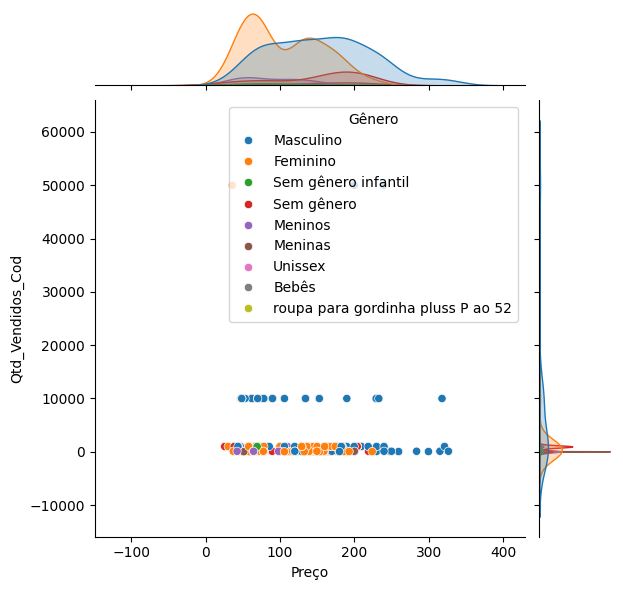

In [ ]:
sns.jointplot(x='Preço', y='Qtd_Vendidos_Cod',hue='Gênero', data=df, kind='scatter') # ('scatter, 'hist', 'hex', 'kde', 'reg', 'resid')
plt.show()


# Mapa de Calor

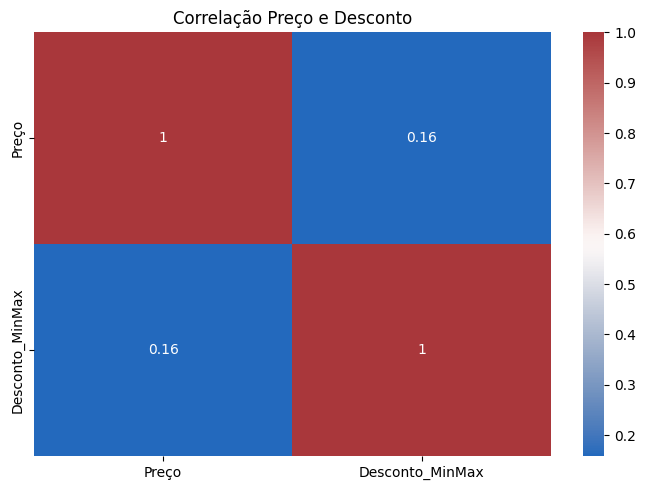

In [ ]:
corr = df[['Preço', 'Desconto_MinMax']].corr()
plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap='vlag')
plt.title('Correlação Preço e Desconto')
plt.tight_layout()
plt.show()

# Gráfico de Barra

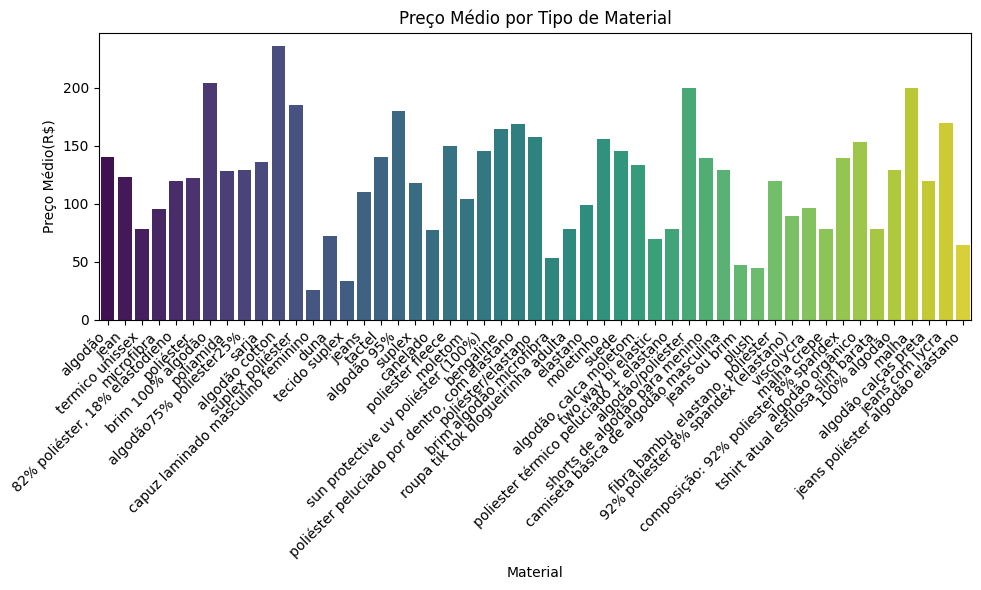

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Material', y='Preço', data=df, estimator='mean', errorbar=None,hue='Material', legend=False,palette='viridis')
plt.title('Preço Médio por Tipo de Material')
plt.xlabel('Material')
plt.ylabel('Preço Médio(R$)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Gráfico de Pizza

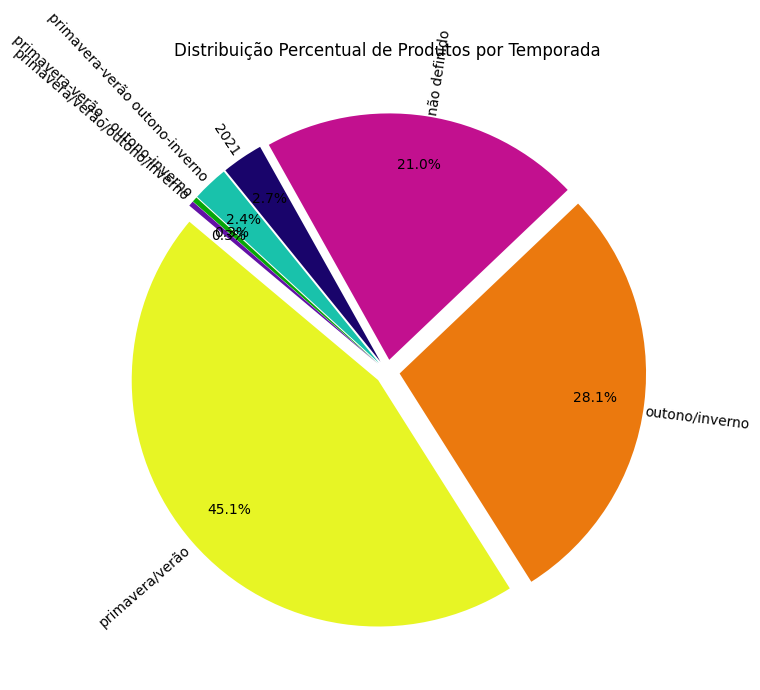

In [ ]:
contagem_temporada = df['Temporada'].value_counts()
plt.figure(figsize=(8, 8))
explode=[0.05] * len(contagem_temporada)
plt.pie(contagem_temporada, labels=contagem_temporada.index, autopct='%1.1f%%', startangle=140, colors=['#e7f525','#eb790e','#c2108f','#19046b','#19c2ab','#07a607','#6311a6'],explode=explode,
        pctdistance=0.8, labeldistance=1.0, rotatelabels=True,)
plt.title('Distribuição Percentual de Produtos por Temporada')
plt.show()

# Gráfico de Densidade

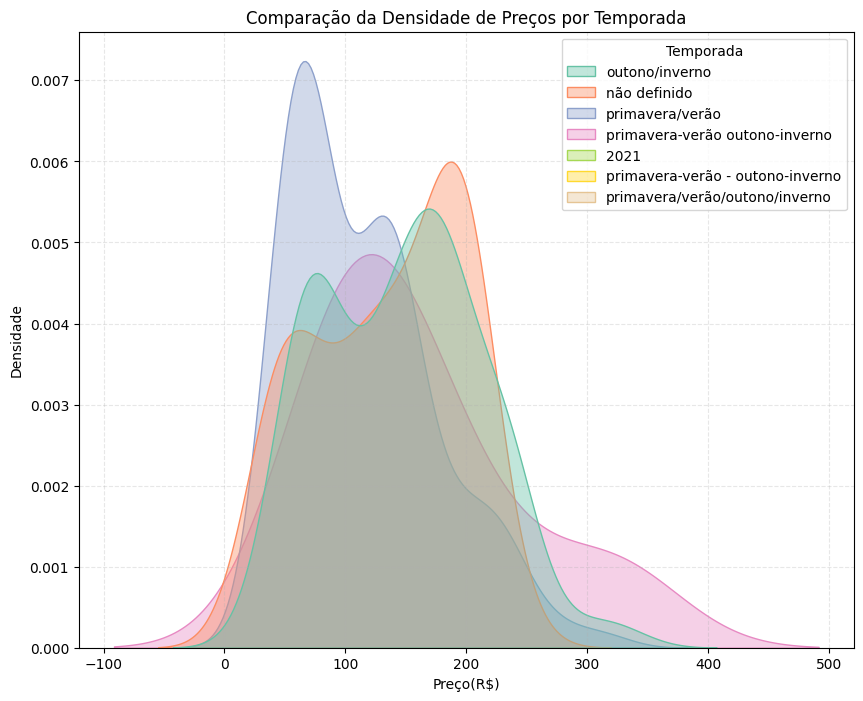

In [ ]:
plt.figure(figsize=(10, 8))
sns.kdeplot(data=df, x='Preço', hue='Temporada', fill=True,common_norm=False, alpha=0.4,palette='Set2',warn_singular=False,)
plt.title('Comparação da Densidade de Preços por Temporada')
plt.xlabel('Preço(R$)')
plt.ylabel('Densidade')
plt.grid(True, linestyle = '--', alpha=0.3)
plt.show()

# Gráfico de Regressão

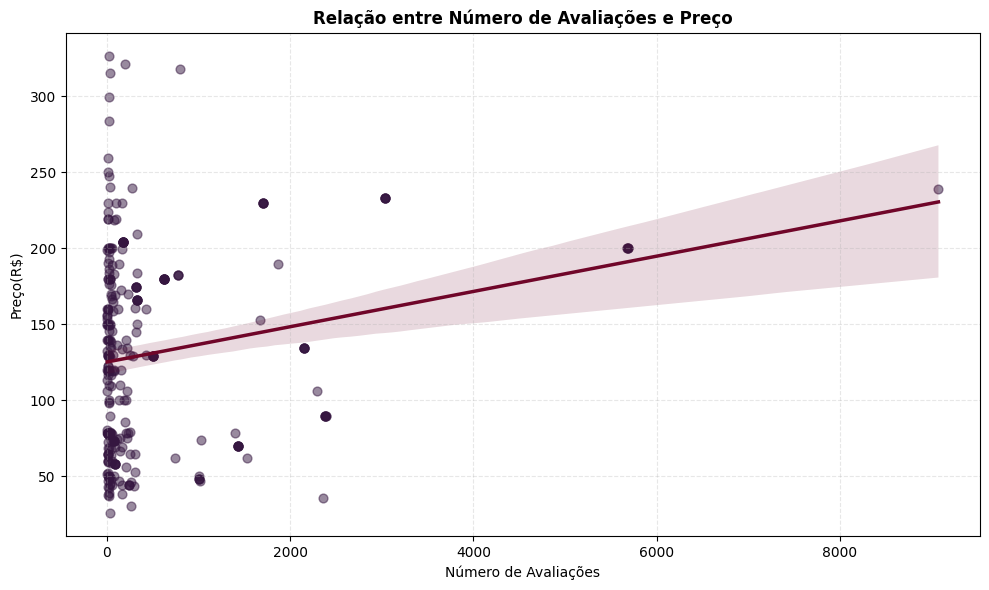

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='N_Avaliações', y='Preço',  color='#8a880c', scatter_kws={'alpha': 0.5,'s':40,'color': '#351640'},
line_kws={'color':'#700629','linewidth':2.5})
plt.title('Relação entre Número de Avaliações e Preço', fontsize=12, fontweight='bold')
plt.xlabel('Número de Avaliações')
plt.ylabel('Preço(R$)')
plt.grid(True, linestyle = '--', alpha=0.3)
plt.tight_layout()
plt.show()